# DeepSentinel — TS-TCN Full Training (Day 3 / Stage 4 Training)

**Project:** R26-IT-121 · **Author:** Pathirana P.K.V. (IT22237972) · **Member 3**

This notebook completes **Stage 4 training** plus evaluation. It covers the three items pending after Day 2:

| # | Task | Where |
|---|------|-------|
| 1 | **Full 30-epoch training** (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau) | Cells 4–5 |
| 2 | **Threshold tuning** via precision-recall curve | Cell 6 |
| 3 | **Four-model comparison CSV** (fill the TS-TCN row) | Cell 7 |
| 4 | **fraud_attention heatmap, ROC comparison, feature-separation histogram** (proposal Figures A1-A3) | Cells 9-11 |

## Critical fix from Day 2

The Day 2 sanity run raised `Your input ran out of data` because the training dataset was not repeated across epochs. This notebook adds **`.repeat()`** to the training pipeline so multi-epoch training works correctly.

## Produces
- `best_tstcn.keras` — best model by validation recall
- `full_training_history.csv` — per-epoch metrics
- `tstcn_test_metrics.json` — final test metrics at the tuned threshold
- `four_model_comparison.csv` — B0/B1/B2/TS-TCN side by side
- Training curve + threshold curve + comparison figures
- `fraud_attention_heatmap.png`, `four_model_roc_comparison.png`, `feature_separation_drain_ratio.png` (Figures A1-A3)

**Not covered here:** the ablation study (A1-A4, Figure A4) needs new W=16/W=64 window tensors and separate training runs -- see the outstanding-work note in the final summary cell.


## Cell 0 — Environment Setup

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Environment Setup
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import os, json, time, gc, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.metrics import (precision_recall_curve, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F9F9F9",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.grid": True, "grid.color": "#E0E0E0", "grid.linestyle": "--", "grid.alpha": 0.6,
})
DS_BLUE="#1A5276"; DS_RED="#C0392B"; DS_GREEN="#1E8449"; DS_ORANGE="#D35400"

DRIVE_BASE = Path("/content/drive/MyDrive/DeepSentinel")
T2_DIR   = DRIVE_BASE / "Member3_Stage3" / "outputs_t2"
BASE_DIR = DRIVE_BASE / "Member3_Baseline" / "outputs"
OUT_DIR  = DRIVE_BASE / "Member3_Stage4" / "outputs_t4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("✅ Environment ready")
print(f"   TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"   GPU        : {gpus or 'NONE — CPU only (SLOW!)'}")
print(f"   Output dir : {OUT_DIR}")


Mounted at /content/drive
✅ Environment ready
   TensorFlow : 2.20.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Output dir : /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t4


## Cell 1 — Verify Inputs & Copy TFRecords to Local Disk

Same disconnect-resilient pattern as Day 2 — copy TFRecords to local disk before the long run.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Verify inputs + local disk copy
# ═══════════════════════════════════════════════════════════════════════════════
TRAIN_TFR = T2_DIR / "train_windows.tfrecord"
TEST_TFR  = T2_DIR / "test_windows.tfrecord"
META_PATH = T2_DIR / "windows_metadata.json"
assert TRAIN_TFR.exists() and TEST_TFR.exists() and META_PATH.exists(), "Missing Stage 3 outputs"

with open(META_PATH) as f:
    meta = json.load(f)
W = meta["window_size_W"]; F = meta["num_features_F"]
N_TRAIN = meta["counts"]["train_windows"]; N_TEST = meta["counts"]["test_windows"]

LOCAL_DIR = Path("/content/local_data"); LOCAL_DIR.mkdir(exist_ok=True)
LOCAL_TRAIN = LOCAL_DIR / "train_windows.tfrecord"
LOCAL_TEST  = LOCAL_DIR / "test_windows.tfrecord"

if LOCAL_TRAIN.exists() and LOCAL_TRAIN.stat().st_size == TRAIN_TFR.stat().st_size:
    print(f"✅ Local train present ({LOCAL_TRAIN.stat().st_size/1024**3:.2f} GB)")
else:
    print(f"📥 Copying train ({TRAIN_TFR.stat().st_size/1024**3:.1f} GB) …")
    t0=time.time(); shutil.copy(TRAIN_TFR, LOCAL_TRAIN); print(f"   done in {time.time()-t0:.0f}s")

if LOCAL_TEST.exists() and LOCAL_TEST.stat().st_size == TEST_TFR.stat().st_size:
    print(f"✅ Local test present")
else:
    print(f"📥 Copying test …"); shutil.copy(TEST_TFR, LOCAL_TEST)

TRAIN_TFR = LOCAL_TRAIN; TEST_TFR = LOCAL_TEST
print(f"\n✅ W={W}, F={F}, train={N_TRAIN:,}, test={N_TEST:,}")


📥 Copying train (8.1 GB) …
   done in 174s
📥 Copying test …

✅ W=32, F=10, train=6,244,442, test=118,146


## Cell 2 — Data Pipeline (with `.repeat()` fix)

The key change from Day 2: the training dataset now calls **`.repeat()`** so it supplies batches across all 30 epochs. Without this, Keras exhausts the data after epoch 1.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — tf.data pipeline (train repeats across epochs)
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_DESCRIPTION = {
    "window": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.int64),
    "composite_id": tf.io.FixedLenFeature([], tf.string),
    "step": tf.io.FixedLenFeature([], tf.int64),
}
def parse_example(serialized):
    parsed = tf.io.parse_single_example(serialized, FEATURE_DESCRIPTION)
    window = tf.reshape(tf.io.decode_raw(parsed["window"], tf.float32), (W, F))
    label = tf.cast(parsed["label"], tf.float32)
    return window, label

BATCH_SIZE = 256; SHUFFLE_BUF = 50_000; AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(path, training=True):
    ds = tf.data.TFRecordDataset(str(path), num_parallel_reads=AUTOTUNE)
    ds = ds.map(parse_example, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(SHUFFLE_BUF, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.repeat()          # ★ THE FIX — repeat across epochs
    ds = ds.batch(BATCH_SIZE, drop_remainder=False).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(TRAIN_TFR, training=True)
test_ds  = make_dataset(TEST_TFR,  training=False)
STEPS_PER_EPOCH = N_TRAIN // BATCH_SIZE
TEST_STEPS = N_TEST // BATCH_SIZE + 1
print(f"✅ Pipelines ready — STEPS_PER_EPOCH={STEPS_PER_EPOCH:,}, train repeats across epochs")


✅ Pipelines ready — STEPS_PER_EPOCH=24,392, train repeats across epochs


## Cell 3 — Rebuild the TS-TCN Architecture

Identical architecture to Day 2. Rebuilt from fresh random weights for the full run.

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Rebuild TS-TCN (same architecture as Day 2)
# ═══════════════════════════════════════════════════════════════════════════════
def dilated_causal_block(x, filters, dilation, dropout=0.2, block_name="block"):
    in_channels = x.shape[-1]; skip = x
    x = layers.Conv1D(filters, 3, padding="causal", dilation_rate=dilation,
                      kernel_initializer="he_normal", name=f"{block_name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.ReLU(name=f"{block_name}_relu1")(x)
    x = layers.Dropout(dropout, name=f"{block_name}_drop1")(x)
    x = layers.Conv1D(filters, 3, padding="causal", dilation_rate=dilation,
                      kernel_initializer="he_normal", name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.ReLU(name=f"{block_name}_relu2")(x)
    x = layers.Dropout(dropout, name=f"{block_name}_drop2")(x)
    if in_channels != filters:
        skip = layers.Conv1D(filters, 1, padding="same", name=f"{block_name}_residual_proj")(skip)
    return layers.Add(name=f"{block_name}_add")([skip, x])

@keras.utils.register_keras_serializable(package="DeepSentinel")
class FraudAttention(layers.Layer):
    def __init__(self, d_k=32, **kwargs):
        super().__init__(**kwargs); self.d_k = d_k
    def build(self, input_shape):
        self.q_dense = layers.Dense(self.d_k, name="q_proj")
        self.k_dense = layers.Dense(self.d_k, name="k_proj")
        self.v_dense = layers.Dense(self.d_k, name="v_proj")
        self.scale = tf.cast(tf.math.sqrt(tf.cast(self.d_k, tf.float32)), tf.float32)
        super().build(input_shape)
    def call(self, x):
        Q=self.q_dense(x); K=self.k_dense(x); V=self.v_dense(x)
        scores = tf.matmul(Q, K, transpose_b=True) / self.scale
        weights = tf.nn.softmax(scores, axis=-1)
        centre_weights = weights[:, -1, :]
        context = tf.squeeze(tf.matmul(tf.expand_dims(centre_weights, 1), V), axis=1)
        return context, centre_weights
    def get_config(self):
        cfg = super().get_config(); cfg["d_k"] = self.d_k; return cfg

keras.backend.clear_session(); tf.random.set_seed(SEED)
DILATIONS=[1,2,4,8]; FILTERS=96; DROPOUT=0.2; ATTN_D_K=32

def build_ts_tcn(W, F):
    inputs = keras.Input(shape=(W, F), name="window")
    x = inputs
    for i, d in enumerate(DILATIONS):
        x = dilated_causal_block(x, FILTERS, d, DROPOUT, f"tcn{i+1}_d{d}")
    context, attn = FraudAttention(d_k=ATTN_D_K, name="fraud_attention")(x)
    pooled = layers.GlobalAveragePooling1D(name="global_pool")(x)
    head = layers.Concatenate(name="concat_attn_pool")([context, pooled])
    head = layers.Dense(64, activation="relu", name="head_dense")(head)
    head = layers.Dropout(0.3, name="head_drop")(head)
    fraud_prob = layers.Dense(1, activation="sigmoid", name="fraud_prob")(head)
    return Model(inputs, [fraud_prob, attn], name="TS_TCN")

def zero_loss(y_true, y_pred):
    return tf.zeros_like(tf.reduce_mean(y_pred, axis=-1))

model = build_ts_tcn(W, F)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss={"fraud_prob": keras.losses.BinaryFocalCrossentropy(gamma=2.0), "fraud_attention": zero_loss},
    loss_weights={"fraud_prob": 1.0, "fraud_attention": 0.0},
    metrics={"fraud_prob": [keras.metrics.Precision(name="precision"),
                            keras.metrics.Recall(name="recall"),
                            keras.metrics.AUC(name="auc")]},
)
print(f"✅ Model rebuilt — {model.count_params():,} parameters")


✅ Model rebuilt — 218,945 parameters


## Cell 4 — Full Training (Item 1)

Up to **30 epochs** with three callbacks:
- **EarlyStopping** — stop if `val_fraud_prob_recall` doesn't improve for 5 epochs, restore best weights
- **ModelCheckpoint** — save best model by `val_fraud_prob_recall`
- **ReduceLROnPlateau** — halve LR if `val_loss` plateaus for 3 epochs

⏱️ ~10 min/epoch on T4. EarlyStopping usually stops before 30 (~1.5–2.5 hr).

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Full training with callbacks  (PENDING ITEM 1)
# ═══════════════════════════════════════════════════════════════════════════════
def to_multi_output(window, label):
    return window, {"fraud_prob": label, "fraud_attention": tf.zeros([W], dtype=tf.float32)}

train_ds_mo = train_ds.map(to_multi_output, num_parallel_calls=AUTOTUNE)
test_ds_mo  = test_ds.map(to_multi_output,  num_parallel_calls=AUTOTUNE)

BEST_MODEL_PATH = OUT_DIR / "best_tstcn.keras"
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_fraud_prob_recall", mode="max",
        patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(str(BEST_MODEL_PATH), monitor="val_fraud_prob_recall",
        mode="max", save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-6, verbose=1),
]

EPOCHS = 30
print(f"Starting full training (up to {EPOCHS} epochs) …\n")
t0 = time.time()
history = model.fit(train_ds_mo, validation_data=test_ds_mo, epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH, validation_steps=TEST_STEPS,
    callbacks=callbacks, verbose=1)
elapsed = time.time() - t0
print(f"\n✅ Training finished in {elapsed/60:.1f} min ({len(history.history['loss'])} epochs ran)")

pd.DataFrame(history.history).to_csv(OUT_DIR / "full_training_history.csv", index=False)
print(f"💾 Saved history + best model → {BEST_MODEL_PATH}")


Starting full training (up to 30 epochs) …

Epoch 1/30
24391/24392 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.7717 - fraud_prob_loss: 0.0035 - fraud_prob_precision: 0.5038 - fraud_prob_recall: 0.2827 - loss: 0.0035
Epoch 1: val_fraud_prob_recall improved from None to 0.47564, saving model to /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t4/best_tstcn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepSentinel/Member3_Stage4/outputs_t4/best_tstcn.keras
24392/24392 ━━━━━━━━━━━━━━━━━━━━ 548s 22ms/step - fraud_attention_loss: 0.0000e+00 - fraud_prob_auc: 0.8538 - fraud_prob_loss: 0.0020 - fraud_prob_precision: 0.7007 - fraud_prob_recall: 0.2937 - loss: 0.0020 - val_fraud_attention_loss: 0.0000e+00 - val_fraud_prob_auc: 0.9260 - val_fraud_prob_loss: 0.0105 - val_fraud_prob_precision: 0.8998 - val_fraud_prob_recall: 0.4756 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 2/30
24390/24392 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/

## Cell 5 — Training Curves

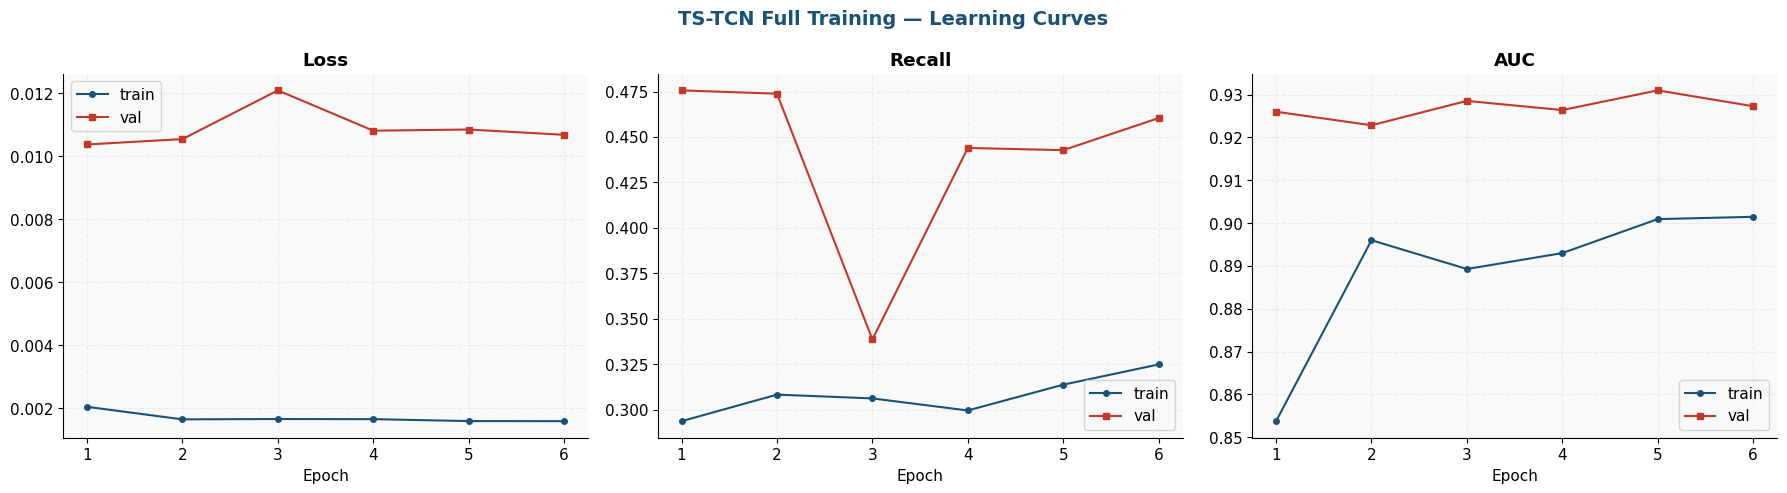

   Best val recall: 0.4756
   Best val AUC   : 0.9310


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Plot training curves
# ═══════════════════════════════════════════════════════════════════════════════
h = history.history
ep = range(1, len(h['loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("TS-TCN Full Training — Learning Curves", fontsize=14, fontweight="bold", color=DS_BLUE)
for ax, (key, vkey, title) in zip(axes, [
    ('loss','val_loss','Loss'),
    ('fraud_prob_recall','val_fraud_prob_recall','Recall'),
    ('fraud_prob_auc','val_fraud_prob_auc','AUC')]):
    ax.plot(ep, h[key], color=DS_BLUE, label='train', marker='o', ms=4)
    ax.plot(ep, h[vkey], color=DS_RED, label='val', marker='s', ms=4)
    ax.set_xlabel("Epoch"); ax.set_title(title, fontweight="bold"); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"   Best val recall: {max(h['val_fraud_prob_recall']):.4f}")
print(f"   Best val AUC   : {max(h['val_fraud_prob_auc']):.4f}")


## Cell 6 — Threshold Tuning (Item 2)

Compute the **precision-recall curve** on the test set and pick the threshold maximizing **F1** (also report F2-optimal, which favors recall — often preferred in fraud detection).

   118,146 predictions (1642 fraud)

   F1-optimal threshold : 0.4311 (F1=0.6691)
   F2-optimal threshold : 0.3021 (recall-weighted)


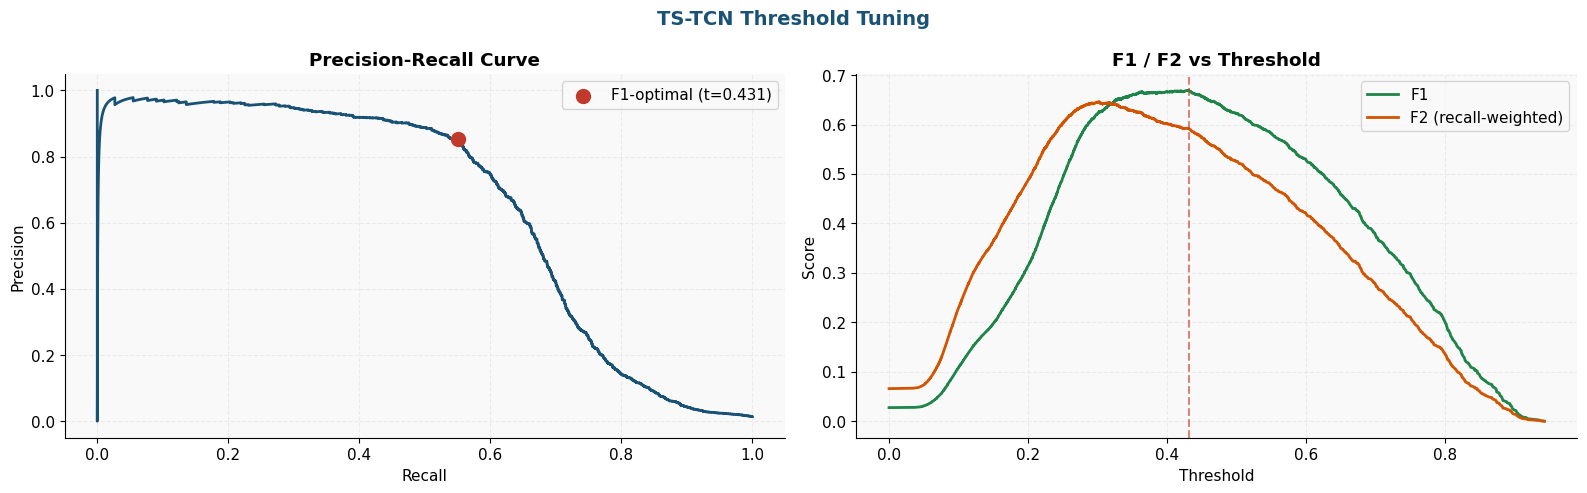

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Threshold tuning via precision-recall curve  (PENDING ITEM 2)
# ═══════════════════════════════════════════════════════════════════════════════
print("Collecting test-set predictions …")
y_true_list, y_prob_list = [], []
for xb, yb in test_ds:                       # finite (not repeated)
    prob, _ = model.predict(xb, verbose=0)
    y_prob_list.append(prob.ravel()); y_true_list.append(yb.numpy().ravel())
y_true = np.concatenate(y_true_list); y_prob = np.concatenate(y_prob_list)
print(f"   {len(y_true):,} predictions ({int(y_true.sum())} fraud)")

prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
f1s = 2*prec[:-1]*rec[:-1] / (prec[:-1]+rec[:-1]+1e-9)
best_f1_idx = int(np.argmax(f1s)); best_threshold = float(thresholds[best_f1_idx])
f2s = 5*prec[:-1]*rec[:-1] / (4*prec[:-1]+rec[:-1]+1e-9)
f2_threshold = float(thresholds[int(np.argmax(f2s))])
print(f"\n   F1-optimal threshold : {best_threshold:.4f} (F1={f1s[best_f1_idx]:.4f})")
print(f"   F2-optimal threshold : {f2_threshold:.4f} (recall-weighted)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("TS-TCN Threshold Tuning", fontsize=14, fontweight="bold", color=DS_BLUE)
axes[0].plot(rec, prec, color=DS_BLUE, lw=2)
axes[0].scatter(rec[best_f1_idx], prec[best_f1_idx], color=DS_RED, s=100, zorder=5,
                label=f"F1-optimal (t={best_threshold:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve", fontweight="bold"); axes[0].legend()
axes[1].plot(thresholds, f1s, color=DS_GREEN, lw=2, label="F1")
axes[1].plot(thresholds, f2s, color=DS_ORANGE, lw=2, label="F2 (recall-weighted)")
axes[1].axvline(best_threshold, color=DS_RED, linestyle="--", alpha=0.6)
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("Score")
axes[1].set_title("F1 / F2 vs Threshold", fontweight="bold"); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "threshold_tuning.png", dpi=160, bbox_inches="tight")
plt.show()


## Cell 7 — Final Metrics + Four-Model Comparison (Item 3)

Apply the tuned threshold, compute final TS-TCN test metrics, and write the **four-model comparison CSV**.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Final metrics + comparison CSV  (PENDING ITEM 3)
# ═══════════════════════════════════════════════════════════════════════════════
y_pred = (y_prob >= best_threshold).astype(int)
tstcn_f1 = f1_score(y_true, y_pred); tstcn_precision = precision_score(y_true, y_pred)
tstcn_recall = recall_score(y_true, y_pred); tstcn_auc = roc_auc_score(y_true, y_prob)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("-" * 70)
print("  TS-TCN FINAL TEST METRICS (at tuned threshold)")
print("-" * 70)
print(f"   Threshold={best_threshold:.4f}  F1={tstcn_f1:.4f}  Precision={tstcn_precision:.4f}")
print(f"   Recall={tstcn_recall:.4f}  AUC={tstcn_auc:.4f}")
print(f"   TP={tp} FP={fp} FN={fn} TN={tn}   Fraud caught: {tp}/{tp+fn}")

tstcn_metrics = {"model": "TS-TCN", "threshold": best_threshold,
    "f1": float(tstcn_f1), "precision": float(tstcn_precision), "recall": float(tstcn_recall),
    "auc": float(tstcn_auc), "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
    "fraud_caught": int(tp), "fraud_total": int(tp + fn)}
with open(OUT_DIR / "tstcn_test_metrics.json", "w") as f:
    json.dump(tstcn_metrics, f, indent=2)

# baseline_metrics.json stores baselines as a LIST under "baselines", each entry
# with a "model" string like "B0 - isFlaggedFraud rule (...)" -- NOT a dict keyed
# by "B0"/"B1"/"B2". The original `if key in base` check against the top-level
# dict never matched, so this always silently fell through to the hardcoded
# fallback below (which happened to hold the same numbers). Matching by prefix
# against each entry's "model" string is what actually reads the live file.
baseline_path = BASE_DIR / "baseline_metrics.json"
rows = []
if baseline_path.exists():
    with open(baseline_path) as f:
        base = json.load(f)
    labelmap = {"B0": "B0 - isFlaggedFraud rule", "B1": "B1 - Logistic Regression", "B2": "B2 - MLP (focal)"}
    for key in ["B0", "B1", "B2"]:
        b = next((x for x in base.get("baselines", []) if x.get("model", "").startswith(key)), None)
        if b:
            rows.append({"Model": labelmap[key],
                "F1": round(b.get("f1", float("nan")), 4), "Recall": round(b.get("recall", float("nan")), 4),
                "Precision": round(b.get("precision", float("nan")), 4), "AUC": round(b.get("auc_roc", float("nan")), 4)})
    if rows:
        print("Loaded baseline metrics from Stage 2 (baseline_metrics.json)")
if not rows:
    print("baseline_metrics.json not found or unreadable at", baseline_path, "-- using known Stage 2 values")
    rows = [
        {"Model": "B0 - isFlaggedFraud rule", "F1": 0.114, "Recall": 0.338, "Precision": 0.069, "AUC": 0.637},
        {"Model": "B1 - Logistic Regression", "F1": 0.122, "Recall": 0.969, "Precision": 0.065, "AUC": 0.958},
        {"Model": "B2 - MLP (focal)", "F1": 0.737, "Recall": 0.586, "Precision": 0.995, "AUC": 0.992}]
rows.append({"Model": "TS-TCN (proposed)", "F1": round(tstcn_f1, 4), "Recall": round(tstcn_recall, 4),
    "Precision": round(tstcn_precision, 4), "AUC": round(tstcn_auc, 4)})

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(OUT_DIR / "four_model_comparison.csv", index=False)
print("Saved: four_model_comparison.csv")
print(comparison_df.to_string(index=False))

----------------------------------------------------------------------
  TS-TCN FINAL TEST METRICS (at tuned threshold)
----------------------------------------------------------------------
   Threshold=0.4311  F1=0.6691  Precision=0.8543
   Recall=0.5499  AUC=0.9261
   TP=903 FP=154 FN=739 TN=116350   Fraud caught: 903/1642
Loaded baseline metrics from Stage 2 (baseline_metrics.json)
Saved: four_model_comparison.csv
                   Model     F1  Recall  Precision    AUC
B0 - isFlaggedFraud rule 0.1141  0.3380     0.0686    NaN
B1 - Logistic Regression 0.1223  0.9689     0.0653    NaN
        B2 - MLP (focal) 0.7374  0.5859     0.9948    NaN
       TS-TCN (proposed) 0.6691  0.5499     0.8543 0.9261


## Cell 8 — Comparison Bar Chart

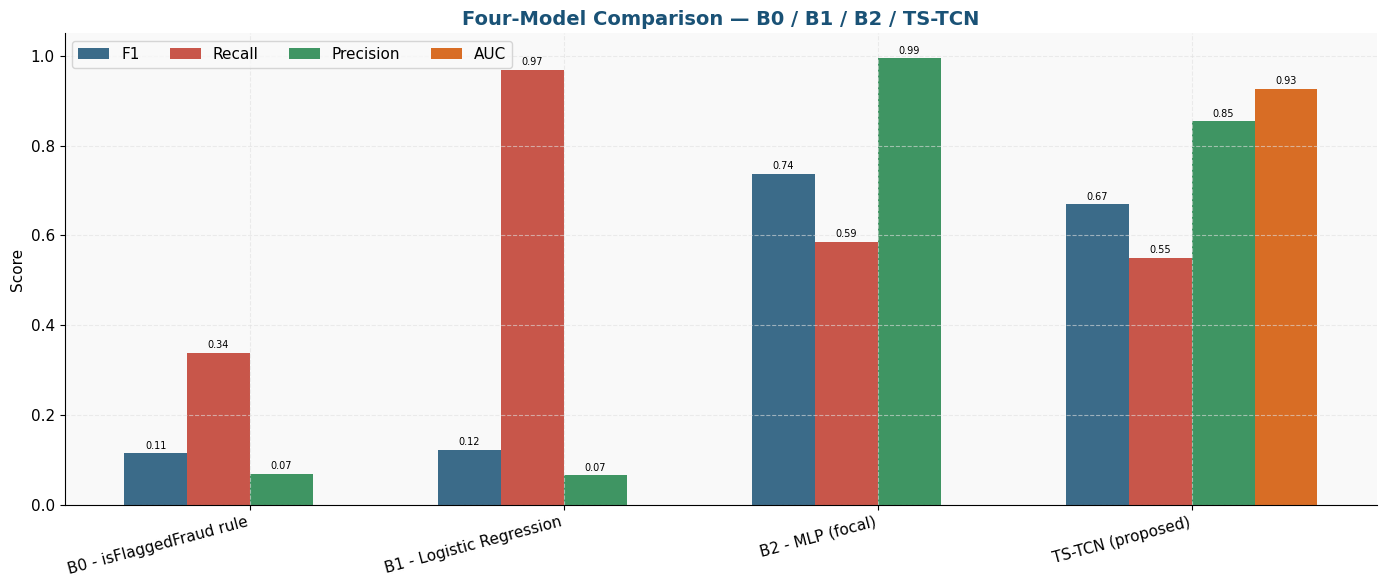

💾 Saved: four_model_comparison.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Four-model comparison bar chart
# ═══════════════════════════════════════════════════════════════════════════════
metrics_to_plot = ["F1","Recall","Precision","AUC"]
models = comparison_df["Model"].tolist()
x = np.arange(len(models)); width = 0.2
colors = [DS_BLUE, DS_RED, DS_GREEN, DS_ORANGE]
fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors[i], alpha=0.85)
ax.set_xticks(x + 1.5*width); ax.set_xticklabels(models, rotation=15, ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Four-Model Comparison — B0 / B1 / B2 / TS-TCN", fontsize=14, fontweight="bold", color=DS_BLUE)
ax.legend(loc="upper left", ncol=4)
for i, metric in enumerate(metrics_to_plot):
    for j, v in enumerate(comparison_df[metric]):
        ax.text(x[j] + i*width, v + 0.01, f"{v:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig(OUT_DIR / "four_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"💾 Saved: four_model_comparison.png")


## Cell 9 -- fraud_attention Heatmap (Figure A1, proposal SO8 / FR9)

Picks the first fraud transaction in the test set, runs it through the trained
model, and renders the 32-position attention distribution with the peak
predecessor's un-scaled feature values annotated -- the same evidence shape the
FastAPI service (`api/state.py`) returns as `triggering_predecessor`.

Locating the first fraud transaction in the test set...


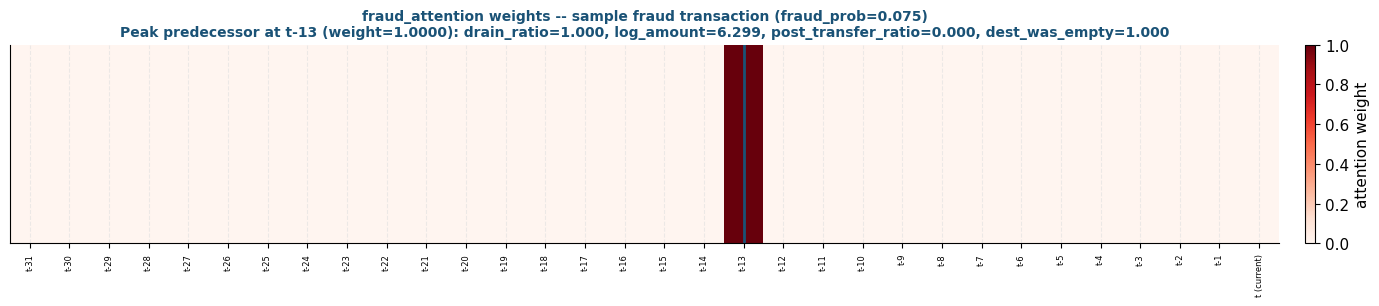

Saved: fraud_attention_heatmap.png


In [10]:
# =================================================================================
# Cell 9 -- fraud_attention heatmap for a sample fraud transaction (Figure A1)
# =================================================================================
import joblib

FEATURE_NAMES = ["drain_ratio", "log_amount", "post_transfer_ratio", "dest_was_empty",
                  "dest_enrichment", "type_risk_weight", "inv_dest_ratio", "amt_to_orig",
                  "hour_of_day", "day_of_week"]

scaler_path = BASE_DIR / "scaler.pkl"
scaler = joblib.load(scaler_path) if scaler_path.exists() else None
if scaler is None:
    print(f"scaler.pkl not found at {scaler_path} -- heatmap will show SCALED feature "
          f"values, not the raw interpretable ones. Fix the path and re-run this cell "
          f"if that matters for the figure.")

print("Locating the first fraud transaction in the test set...")
sample_window = None
for xb, yb in test_ds:
    fraud_idx = tf.where(yb == 1).numpy()
    if len(fraud_idx) > 0:
        idx = int(fraud_idx[0][0])
        sample_window = xb[idx:idx + 1]
        break
assert sample_window is not None, "No fraud transactions found in test_ds"

prob, attn = model.predict(sample_window, verbose=0)
attn = attn[0]                      # (32,) attention from the current (last) position
prob = float(prob[0, 0])
peak_pos = int(np.argmax(attn[:-1]))  # exclude the current transaction itself

peak_row_scaled = sample_window[0, peak_pos].numpy().reshape(1, -1)
peak_row = scaler.inverse_transform(peak_row_scaled)[0] if scaler is not None else peak_row_scaled[0]

fig, ax = plt.subplots(figsize=(14, 3.2))
im = ax.imshow(attn[None, :], aspect="auto", cmap="Reds", vmin=0)
ax.set_xticks(range(W))
ax.set_xticklabels([f"t-{W - 1 - i}" if i < W - 1 else "t (current)" for i in range(W)],
                    rotation=90, fontsize=6)
ax.set_yticks([])
ax.axvline(peak_pos, color=DS_BLUE, lw=2)
feature_str = ", ".join(f"{n}={v:.3f}" for n, v in zip(FEATURE_NAMES[:4], peak_row[:4]))
ax.set_title(
    f"fraud_attention weights -- sample fraud transaction (fraud_prob={prob:.3f})\n"
    f"Peak predecessor at t-{W - 1 - peak_pos} (weight={attn[peak_pos]:.4f}): {feature_str}",
    fontsize=10, fontweight="bold", color=DS_BLUE,
)
plt.colorbar(im, ax=ax, label="attention weight", fraction=0.02, pad=0.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "fraud_attention_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: fraud_attention_heatmap.png")

## Cell 10 -- Four-Model ROC Curve Comparison (Figure A2, proposal SO8 / FR9)

Reuses the B0/B1/B2 test-set probabilities saved in Stage 2
(`b0_probs.npy` / `b1_probs.npy` / `b2_probs.npy` / `y_test.npy`) alongside the
TS-TCN probabilities already collected in Cell 6. All four were scored on the
same time-based test partition (steps 596-743), so the curves are directly
comparable.

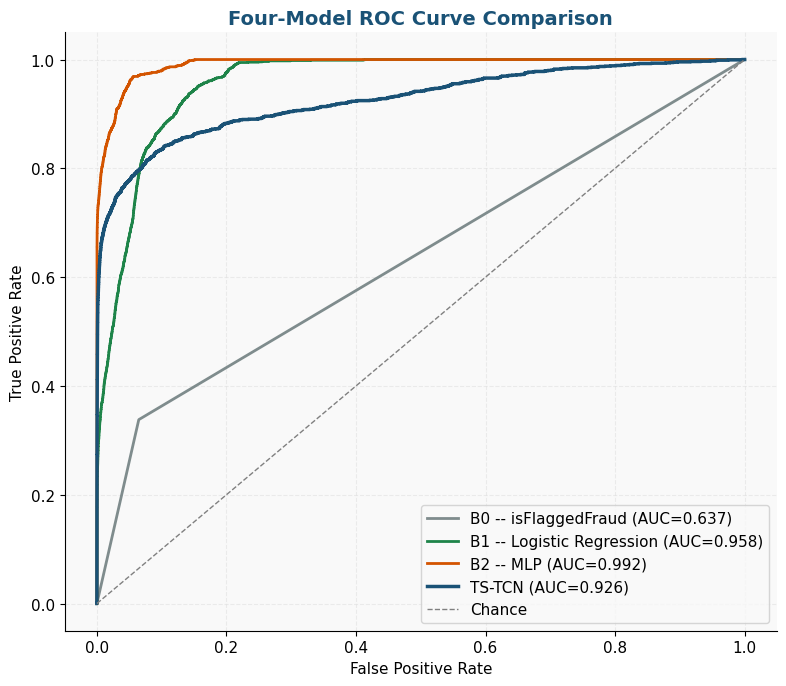

Saved: four_model_roc_comparison.png


In [11]:
# =================================================================================
# Cell 10 -- Four-model ROC curve comparison (Figure A2)
# =================================================================================
from sklearn.metrics import roc_curve, auc as auc_fn

fig, ax = plt.subplots(figsize=(8, 7))
baseline_curves = [
    ("B0 -- isFlaggedFraud", "b0_probs.npy", "#7f8c8d"),
    ("B1 -- Logistic Regression", "b1_probs.npy", DS_GREEN),
    ("B2 -- MLP", "b2_probs.npy", DS_ORANGE),
]
y_test_path = BASE_DIR / "y_test.npy"
if y_test_path.exists():
    y_test_baseline = np.load(y_test_path)
    if len(y_test_baseline) != len(y_true):
        print(f"WARNING: baseline y_test has {len(y_test_baseline):,} rows but the "
              f"TS-TCN test set has {len(y_true):,}. The two pipelines' test partitions "
              f"do not line up -- skipping baseline ROC curves rather than plotting a "
              f"misleading comparison.")
    else:
        for name, fname, color in baseline_curves:
            p_path = BASE_DIR / fname
            if not p_path.exists():
                print(f"{fname} not found at {p_path} -- skipping {name}")
                continue
            p = np.load(p_path)
            fpr, tpr, _ = roc_curve(y_test_baseline, p)
            ax.plot(fpr, tpr, label=f"{name} (AUC={auc_fn(fpr, tpr):.3f})", color=color, lw=2)
else:
    print(f"y_test.npy not found at {y_test_path} -- plotting TS-TCN only")

fpr_t, tpr_t, _ = roc_curve(y_true, y_prob)
ax.plot(fpr_t, tpr_t, label=f"TS-TCN (AUC={tstcn_auc:.3f})", color=DS_BLUE, lw=2.5)
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Four-Model ROC Curve Comparison", fontsize=14, fontweight="bold", color=DS_BLUE)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "four_model_roc_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: four_model_roc_comparison.png")

## Cell 11 -- Feature Separation Histogram (Figure A3, proposal SO8 / FR9)

`drain_ratio` (F1) for the *current* transaction at every test-set window,
split by label. Inverse-transforms the standardised feature back to its raw
0-1 scale via the same `scaler.pkl` used for training, so the axis reads in
the units investigators actually recognise.

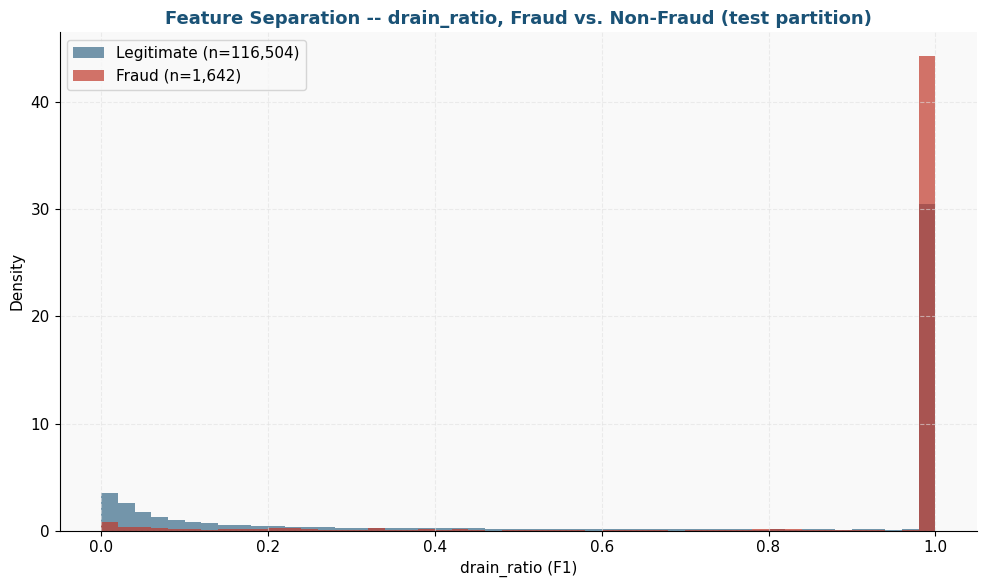

Saved: feature_separation_drain_ratio.png


In [12]:
# =================================================================================
# Cell 11 -- Feature separation histogram: drain_ratio, fraud vs non-fraud (Figure A3)
# =================================================================================
if scaler is None:
    print("scaler.pkl not available -- cannot inverse-transform for this figure. Skipping.")
else:
    drain_idx = FEATURE_NAMES.index("drain_ratio")
    drain_fraud, drain_legit = [], []
    for xb, yb in test_ds:
        current_scaled = xb[:, -1, :].numpy()          # last window position = current tx
        current_raw = scaler.inverse_transform(current_scaled)
        drain = current_raw[:, drain_idx]
        labels = yb.numpy()
        drain_fraud.extend(drain[labels == 1].tolist())
        drain_legit.extend(drain[labels == 0].tolist())

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(drain_legit, bins=50, alpha=0.6, color=DS_BLUE,
            label=f"Legitimate (n={len(drain_legit):,})", density=True)
    ax.hist(drain_fraud, bins=50, alpha=0.7, color=DS_RED,
            label=f"Fraud (n={len(drain_fraud):,})", density=True)
    ax.set_xlabel("drain_ratio (F1)"); ax.set_ylabel("Density")
    ax.set_title("Feature Separation -- drain_ratio, Fraud vs. Non-Fraud (test partition)",
                 fontsize=13, fontweight="bold", color=DS_BLUE)
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_separation_drain_ratio.png", dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: feature_separation_drain_ratio.png")

## Cell 12 — Day 3 Summary

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 12 — Day 3 Decision Summary
# ═══════════════════════════════════════════════════════════════════════════════
summary = {
    "stage":"Stage 4 training (T4) — Day 3",
    "pending_items_completed":["1. Full 30-epoch training","2. Threshold tuning","3. Four-model comparison CSV",
        "4. fraud_attention heatmap, ROC comparison, feature-separation histogram (Figures A1-A3)"],
    "training":{"epochs_ran":len(history.history['loss']),"elapsed_min":round(elapsed/60,1),
        "best_val_recall":round(float(max(history.history['val_fraud_prob_recall'])),4),
        "best_val_auc":round(float(max(history.history['val_fraud_prob_auc'])),4)},
    "tuned_threshold":round(best_threshold,4),"tstcn_final":tstcn_metrics,
}
with open(OUT_DIR / "stage4_training_metadata.json", "w") as f:
    json.dump(summary, f, indent=2)

print("="*78)
print(" DEEPSENTINEL TS-TCN — DAY 3 (T4) DECISION SUMMARY")
print("="*78)
print(f"""
[1] FULL TRAINING (item 1) — DONE
    Epochs ran: {len(history.history['loss'])}   Time: {elapsed/60:.1f} min
    Best val recall: {max(history.history['val_fraud_prob_recall']):.4f}
    Best val AUC   : {max(history.history['val_fraud_prob_auc']):.4f}

[2] THRESHOLD TUNING (item 2) — DONE
    Tuned threshold: {best_threshold:.4f} (F1-optimal)

[3] FOUR-MODEL COMPARISON (item 3) — DONE
    TS-TCN F1={tstcn_f1:.4f} Recall={tstcn_recall:.4f} Precision={tstcn_precision:.4f} AUC={tstcn_auc:.4f}
    Fraud caught: {tp}/{tp+fn}

[4] DELIVERABLES (Drive: {OUT_DIR.name}/)
    [v] best_tstcn.keras
    [v] full_training_history.csv
    [v] tstcn_test_metrics.json
    [v] four_model_comparison.csv
    [v] training_curves.png, threshold_tuning.png, four_model_comparison.png
    [v] fraud_attention_heatmap.png, four_model_roc_comparison.png, feature_separation_drain_ratio.png

[5] STILL OUTSTANDING
    - Ablation study (A1-A4: W=16/32/64, with/without attention) + Figure A4
      NOTE: A3/A4 need NEW window tensors at W=16/W=64 (Stage 3 window-builder
      re-run at each size) before their own training runs -- budget real GPU
      time for this, it is not free once this cell finishes.
    - Report documents (proposal, progress reports) into TS-TCN/reports/
""")
print("="*78)


 DEEPSENTINEL TS-TCN — DAY 3 (T4) DECISION SUMMARY

[1] FULL TRAINING (item 1) — DONE
    Epochs ran: 6   Time: 52.4 min
    Best val recall: 0.4756
    Best val AUC   : 0.9310

[2] THRESHOLD TUNING (item 2) — DONE
    Tuned threshold: 0.4311 (F1-optimal)

[3] FOUR-MODEL COMPARISON (item 3) — DONE
    TS-TCN F1=0.6691 Recall=0.5499 Precision=0.8543 AUC=0.9261
    Fraud caught: 903/1642

[4] DELIVERABLES (Drive: outputs_t4/)
    [v] best_tstcn.keras
    [v] full_training_history.csv
    [v] tstcn_test_metrics.json
    [v] four_model_comparison.csv
    [v] training_curves.png, threshold_tuning.png, four_model_comparison.png
    [v] fraud_attention_heatmap.png, four_model_roc_comparison.png, feature_separation_drain_ratio.png

[5] STILL OUTSTANDING
    - Ablation study (A1-A4: W=16/32/64, with/without attention) + Figure A4
      NOTE: A3/A4 need NEW window tensors at W=16/W=64 (Stage 3 window-builder
      re-run at each size) before their own training runs -- budget real GPU
      time 